In [1]:

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
df = pd.read_csv('../data/ibtracs.NI.list.v04r01.csv', low_memory=False)
print(f"Shape: {df.shape}")
print(f"Cyclones: {df['SID'].nunique()}")

Shape: (62482, 174)
Cyclones: 1846


In [3]:
print("ISO_TIME sample values:")
print(df['ISO_TIME'].head(10).tolist())
print("\nEmpty ISO_TIME count:", (df['ISO_TIME'].isna()| (df['ISO_TIME'] == '')).sum())

mask_imd=df['NEWDELHI_LAT'].notna() & df['NEWDELHI_LON'].notna()
mask_date=df['ISO_TIME'].notna() & (df['ISO_TIME'] != '')

ni_imd=df[mask_imd & mask_date].copy()
ni_imd['time']=pd.to_datetime(ni_imd['ISO_TIME'],errors='coerce')
ni_imd = ni_imd[ni_imd['time']>= '1982-01-01']

print(f"Clean IMD Cyclones (1982+): {ni_imd['SID'].nunique()}")

ISO_TIME sample values:
[' ', '1842-10-25 03:00:00', '1842-10-25 06:00:00', '1842-10-25 09:00:00', '1842-10-25 12:00:00', '1842-10-25 15:00:00', '1842-10-25 18:00:00', '1842-10-25 21:00:00', '1842-10-26 00:00:00', '1842-10-26 03:00:00']

Empty ISO_TIME count: 0
Clean IMD Cyclones (1982+): 449


Found cyclone: 1986228N19120
Raw track length: 177
Clean track length: 0
No valid points, picking first valid...


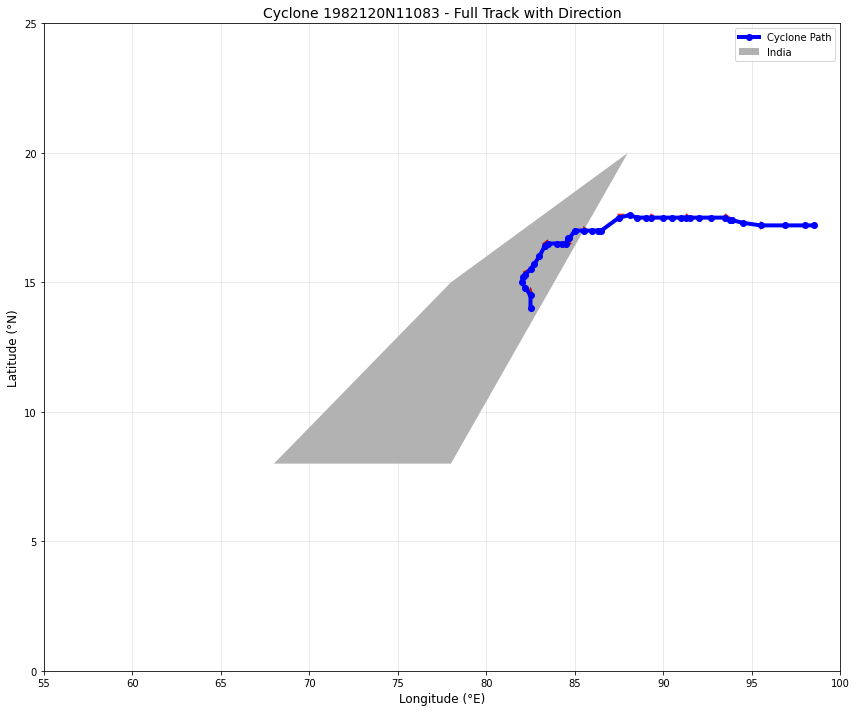

✅ SUCCESS: Cyclone 1982120N11083
Duration: 10.2 days (41 positions)
Lon range: 82.0°E to 98.5°E
Lat range: 14.0°N to 17.6°N


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Pick longest cyclone
longest_cyclone = ni_imd.groupby('SID').size().idxmax()
track = ni_imd[ni_imd['SID'] == longest_cyclone].sort_values('time')

print(f"Found cyclone: {longest_cyclone}")
print(f"Raw track length: {len(track)}")

# SAFE numeric conversion
track['lon'] = pd.to_numeric(track['NEWDELHI_LON'], errors='coerce')
track['lat'] = pd.to_numeric(track['NEWDELHI_LAT'], errors='coerce')

# Drop bad positions
track = track.dropna(subset=['lon', 'lat'])
print(f"Clean track length: {len(track)}")

# SAFETY CHECK - if empty, pick first valid cyclone
if len(track) == 0:
    print("No valid points, picking first valid...")
    valid_sids = ni_imd.dropna(subset=['NEWDELHI_LON', 'NEWDELHI_LAT'])['SID'].unique()
    longest_cyclone = valid_sids[0]
    track = ni_imd[ni_imd['SID'] == longest_cyclone].sort_values('time')
    track['lon'] = pd.to_numeric(track['NEWDELHI_LON'], errors='coerce')
    track['lat'] = pd.to_numeric(track['NEWDELHI_LAT'], errors='coerce')
    track = track.dropna(subset=['lon', 'lat'])

# Create plot
fig, ax = plt.subplots(figsize=(12, 10))
ax.plot(track['lon'], track['lat'], 'b-', linewidth=4, marker='o', markersize=6, label='Cyclone Path')

# *** DIRECTION ARROWS (NEW!) ***
step = max(1, len(track) // 10)  # ~10 arrows total
for i in range(0, len(track)-1, step):
    dx = track['lon'].iloc[i+1] - track['lon'].iloc[i]
    dy = track['lat'].iloc[i+1] - track['lat'].iloc[i]
    ax.arrow(track['lon'].iloc[i], track['lat'].iloc[i], dx, dy, 
             head_width=0.3, head_length=0.3, fc='red', ec='red', alpha=0.8)

# India outline
india_lon = [68, 78, 88, 92, 88, 78, 68]
india_lat = [8,  8,  20, 22, 20, 15, 8]
ax.fill(india_lon, india_lat, 'k', alpha=0.3, label='India')

# Title using SID (handles unnamed)
ax.set_title(f"Cyclone {longest_cyclone} - Full Track with Direction", fontsize=14)
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(55, 100)
ax.set_ylim(0, 25)
plt.tight_layout()
plt.show()

# Print stats
print(f"✅ SUCCESS: Cyclone {longest_cyclone}")
print(f"Duration: {len(track)*6/24:.1f} days ({len(track)} positions)")
print(f"Lon range: {track['lon'].min():.1f}°E to {track['lon'].max():.1f}°E")
print(f"Lat range: {track['lat'].min():.1f}°N to {track['lat'].max():.1f}°N")
